In [24]:
%load_ext autoreload
%autoreload 2

import darts.ad.scorers.scorers
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from darts import TimeSeries

from darts.ad import NormScorer
from darts.models import GlobalNaiveSeasonal, RegressionModel

from nab_utils import load_nab, plot_folder_files, ThresholdConfig


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def distort_time_series(df, anoms=[input_chunk_length'zero'], return_anomalies=False, max_length=108):
    distorted = df.copy()
    original_values = distorted['value']
    distort_length = np.random.randint(1, max_length)

    distorted_values = original_values * 0.95 + original_values.std()*0.1*np.random.choice([1, -1])
    distorted['value'] = distorted_values

    all_anomalies = distorted.timestamp.to_frame()
    all_anomalies['value'] = 0
    if type(anoms) is str:
        anom_key = anoms
        anoms = []
        anoms.append(anom_key)
    for anom_id in range(len(anoms)):
        start_idx = np.random.randint(int(0.7*distorted['timestamp'].size), distorted['timestamp'].size-distort_length)

        anomaly_types = {'zero': 0, 'minor_drop': 0.95, 'moderate_drop': 0.7, 'severe_drop': 0.35, 'critical_drop': 0.15}

        anomaly_values = distorted.loc[start_idx:start_idx+distort_length, "value"] * anomaly_types[anoms[anom_id]]
        distorted.loc[start_idx:start_idx+distort_length, "value"] = anomaly_values


        if return_anomalies:
            all_anomalies.loc[start_idx:start_idx+distort_length, 'value'] = 1
    if not return_anomalies:
        return distorted

    # returns dataframes
    return distorted, all_anomalies

In [3]:
nab_data = load_nab()

<Axes: xlabel='timestamp'>

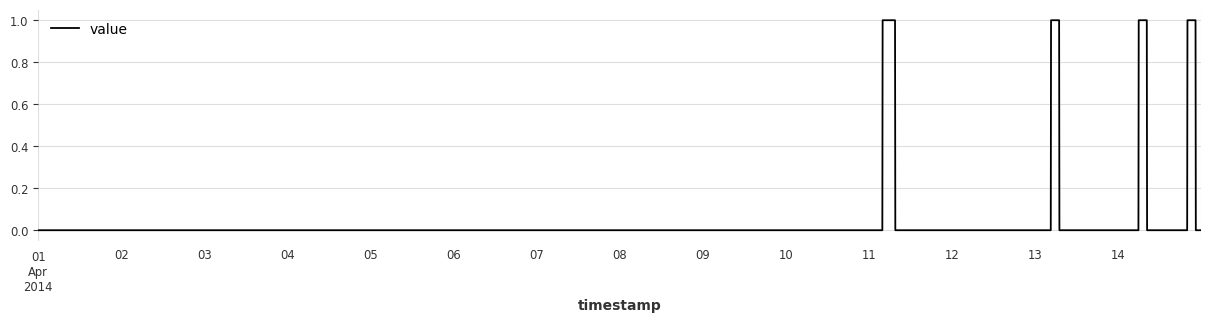

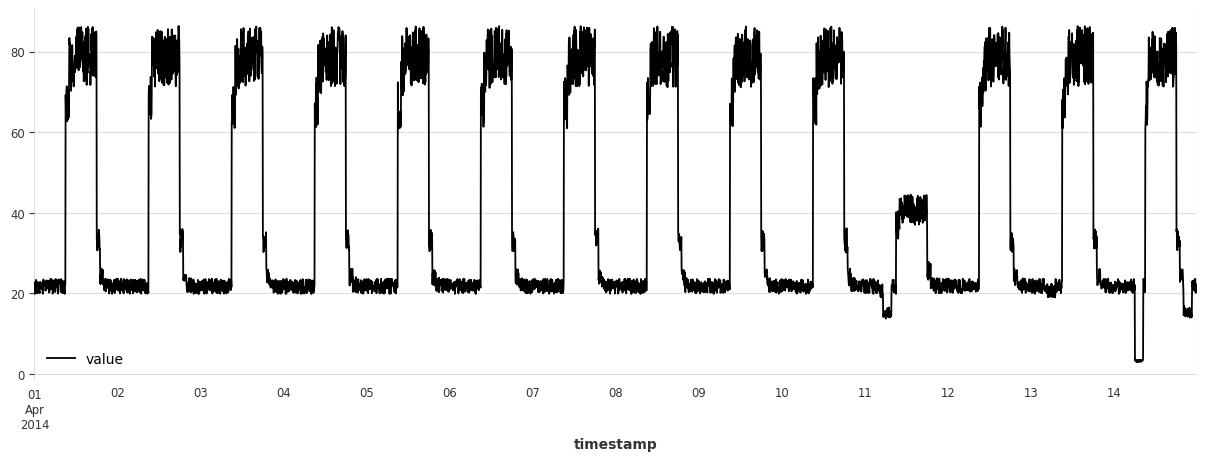

In [4]:
df = nab_data['artificialWithAnomaly']['art_daily_jumpsdown']['df']

anomaly_types = ['zero', 'minor_drop', 'moderate_drop', 'severe_drop', 'critical_drop']
insert_anomalies = []
num_anomalies = 5
for i in range(num_anomalies):
    insert_anomalies.append(anomaly_types[np.random.randint(num_anomalies)])

distort, anomalies = distort_time_series(df, anoms=insert_anomalies, return_anomalies=True)

size = distort['timestamp'].size

fig, axes = plt.subplots(1, figsize=(15,3))

anomalies.plot(x='timestamp', y='value', ax=axes)
fig1 = plt.figure()
ax1 = fig1.add_subplot(111)

fig1.set_figwidth(fig.get_figwidth())
distort.plot(x='timestamp', y='value', ax=ax1)


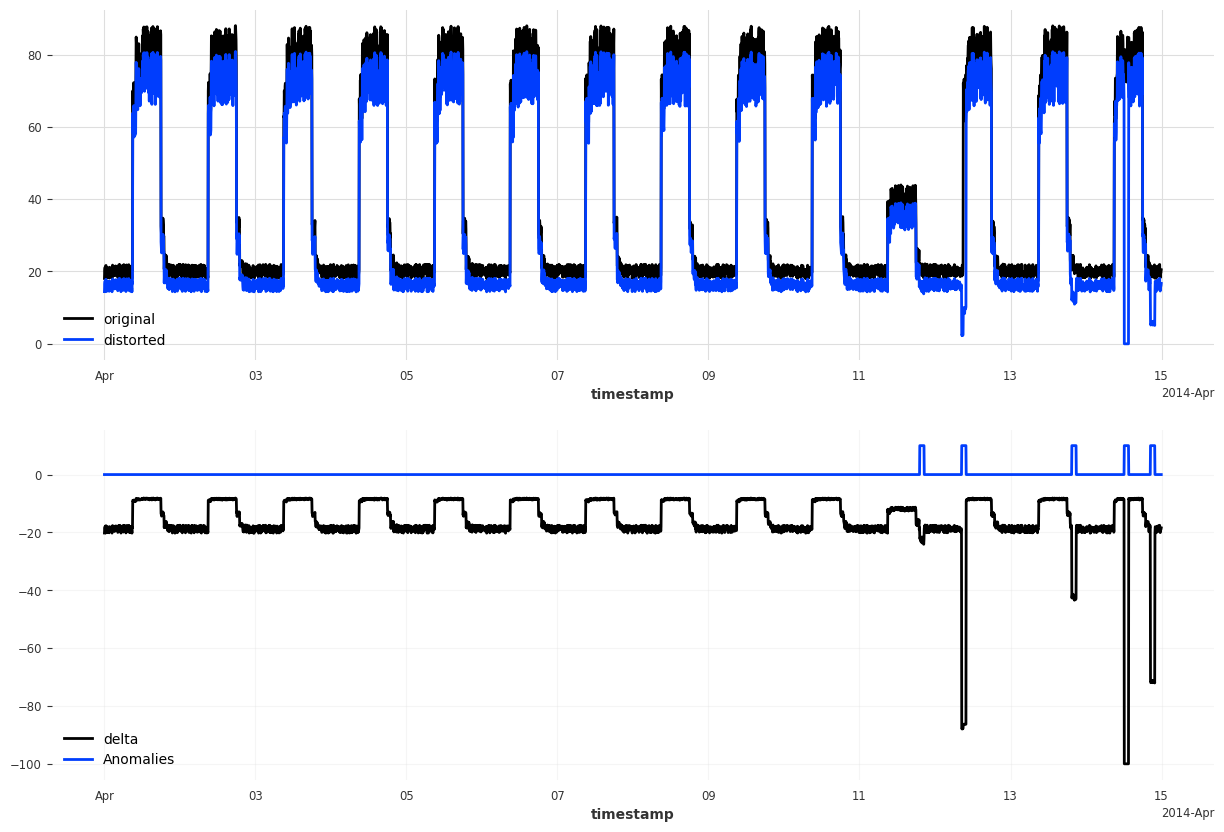

In [5]:
original_df = nab_data['artificialWithAnomaly']['art_daily_jumpsdown']['df']

original_ts = TimeSeries.from_dataframe(original_df, time_col='timestamp')

distorted_df, known_anomalies = distort_time_series(original_df, anoms=anomaly_types, return_anomalies=True)
distorted_ts = TimeSeries.from_dataframe(distorted_df, time_col='timestamp')
anomalies_ts = TimeSeries.from_dataframe(known_anomalies, time_col='timestamp')

difference_ts = ((  distorted_ts-original_ts )/original_ts) * 100

# plt.figure(figsize=(15, 8))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
original_ts.plot(label='original', ax=ax1)
distorted_ts.plot(label='distorted', ax=ax1)
difference_ts.plot(label='delta', ax=ax2)
# known_anomalies.plot(x='timestamp', y='value', label='Anomalies', ax=ax2)
(10*anomalies_ts).plot(label='Anomalies', ax=ax2)
plt.legend()
plt.grid(True, alpha=0.3)


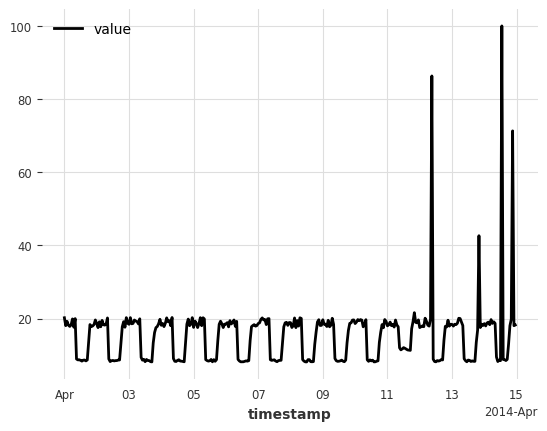

In [6]:
difference_hourly = difference_ts.resample('h').mean()
ax_diff_hourly = abs(difference_hourly).plot(x='timestamp')

<Axes: xlabel='timestamp'>

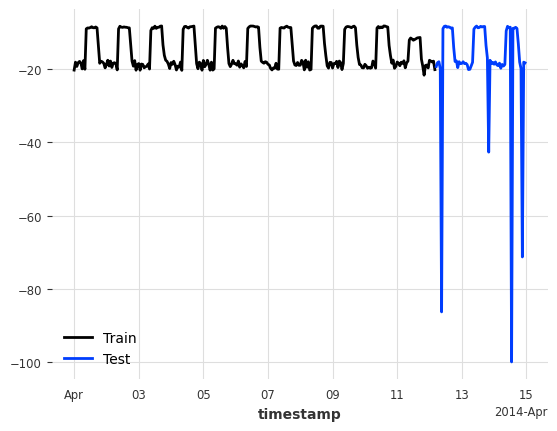

In [7]:
train, test = TimeSeries.split_after(difference_hourly, 0.8)
train.plot(label='Train')
test.plot(label='Test')

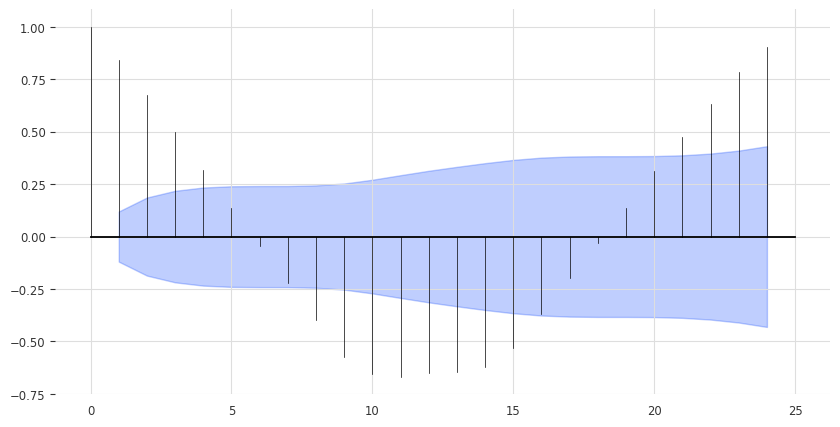

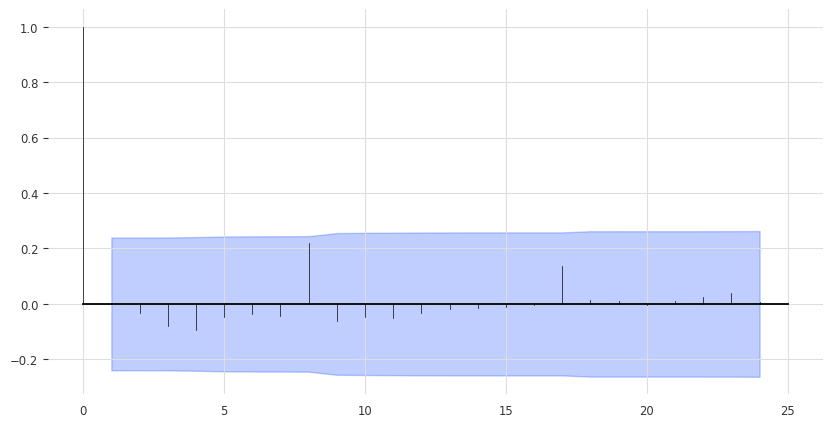

In [8]:
from darts.utils.statistics import plot_acf
plot_acf(train)
plot_acf(test)

In [ ]:
seasonal_model = GlobalNaiveSeasonal(input_chunk_length=24,output_chunk_length=1)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(66)

train.plot(label='Train')
test.plot(label='Test')
seasonal_forecast.plot(label='Forecast')

<Axes: xlabel='timestamp'>

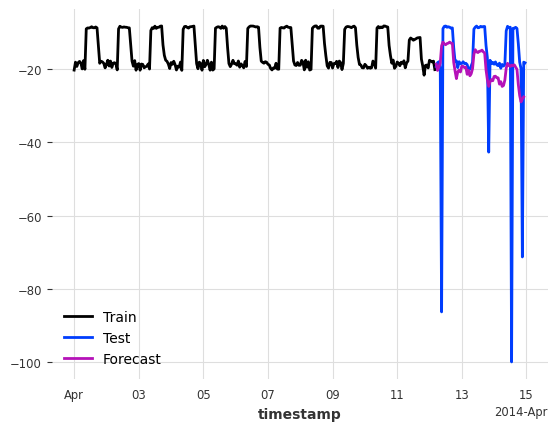

In [25]:
lr_model = RegressionModel(lags=24, output_chunk_length=1)
lr_model.fit(train)
lr_forecast = lr_model.predict(66)
train.plot(label='Train')
test.plot(label='Test')
lr_forecast.plot(label='Forecast')

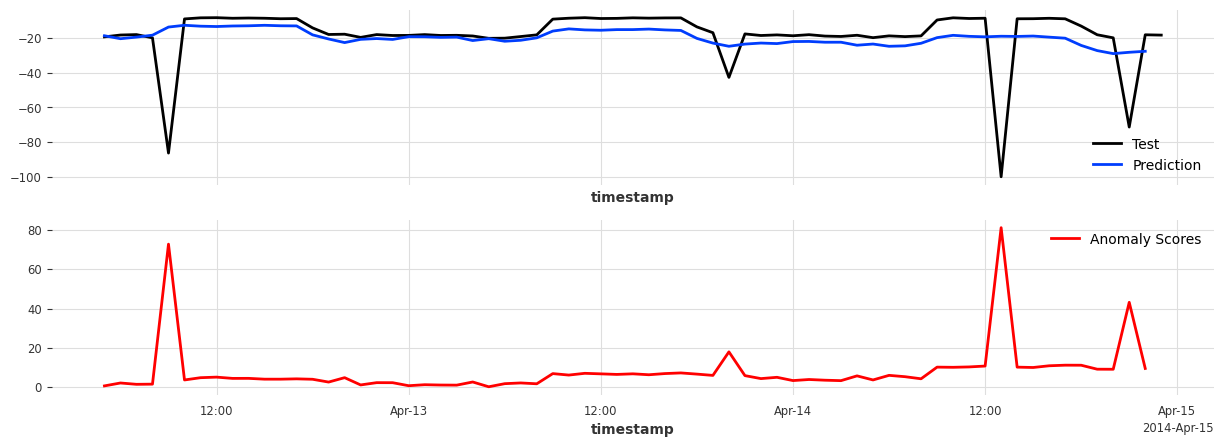

In [26]:

scorer = NormScorer(ord=2)
anomaly_scores = scorer.score_from_prediction(test, lr_forecast)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
test.plot(label='Test', ax=ax1)
lr_forecast.plot(label='Prediction', ax=ax1)
anomaly_scores.plot(label='Anomaly Scores', ax=ax2, color='r')
# difference_hourly.plot(label='Full Series', ax=ax2)
plt.show()


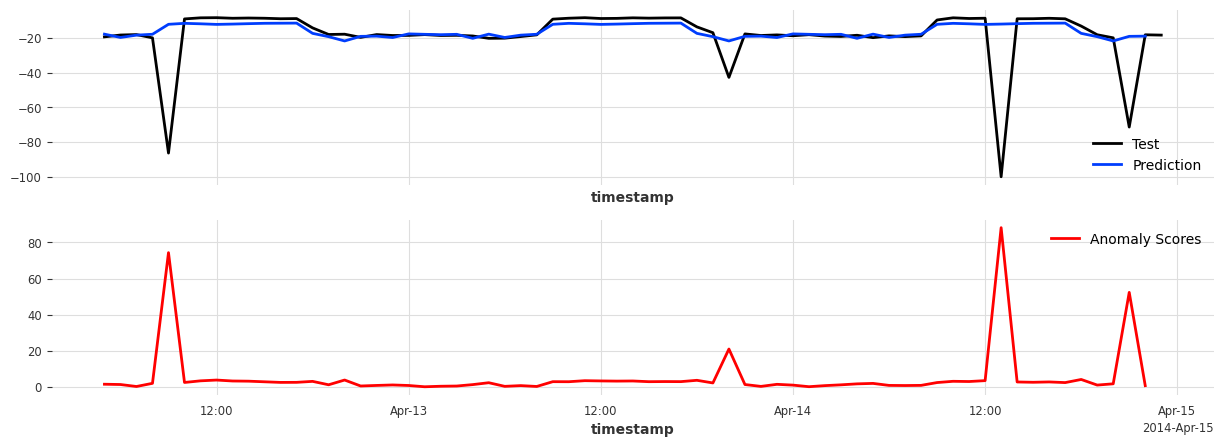

In [10]:
scorer = NormScorer(ord=2)
anomaly_scores = scorer.score_from_prediction(test, seasonal_forecast)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
test.plot(label='Test', ax=ax1)
seasonal_forecast.plot(label='Prediction', ax=ax1)
anomaly_scores.plot(label='Anomaly Scores', ax=ax2, color='r')
# difference_hourly.plot(label='Full Series', ax=ax2)
plt.show()


In [11]:
metric_names = ["AUC_ROC", "AUC_PR"]
metric_data = []
for metric_name in metric_names:
    metric_data.append(
        scorer.eval_metric_from_prediction(
            anomalies=anomalies_ts,
            series=test,
            pred_series=seasonal_forecast,
            metric=metric_name
        )
    )
pd.DataFrame(data=metric_data, index=metric_names)

,0
AUC_ROC,1.0
AUC_PR,1.0


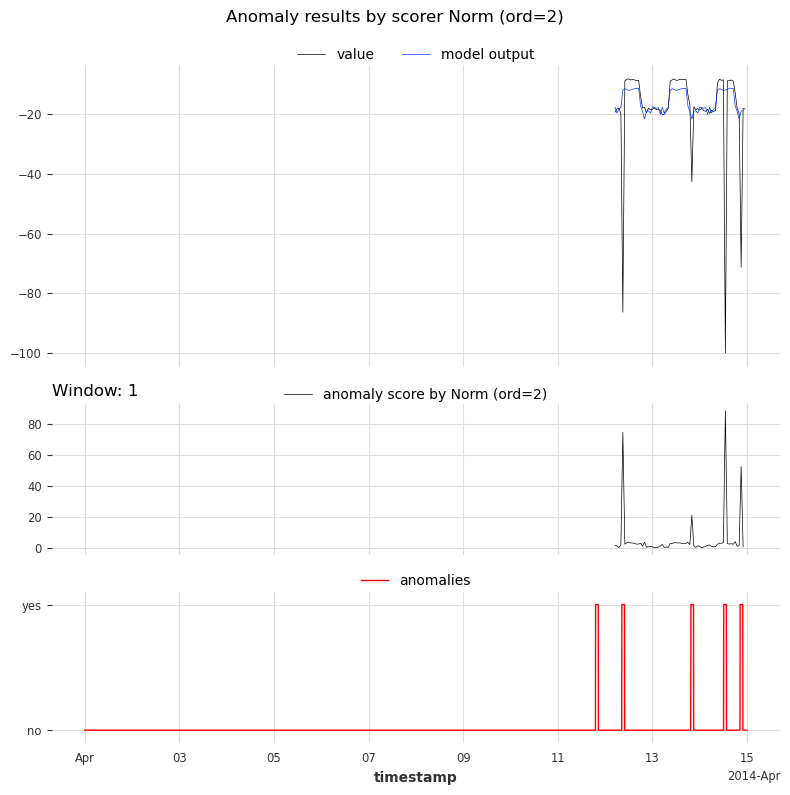

In [12]:
scorer.show_anomalies_from_prediction(test, seasonal_forecast, anomalies=anomalies_ts)

In [13]:
hfc_params = {
    "series": difference_hourly,
    "start": difference_hourly.start_time(),
    "forecast_horizon": 24,
    "verbose": False,
    "show_warnings": False
}

historical_fcast_seasonal = seasonal_model.historical_forecasts(last_points_only=True, **hfc_params)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, u

<Axes: xlabel='timestamp'>

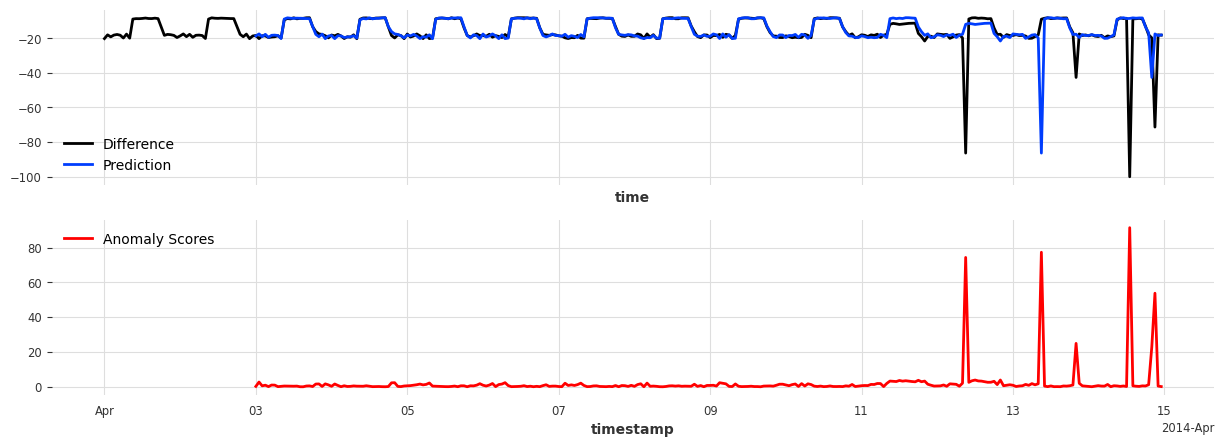

In [14]:
anomaly_scores_historical_fcast = scorer.score_from_prediction(difference_hourly, historical_fcast_seasonal)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
difference_hourly.plot(label='Difference', ax=ax1)
historical_fcast_seasonal.plot(label='Prediction', ax=ax1)
anomaly_scores_historical_fcast.plot(label='Anomaly Scores', ax=ax2, color='r')


In [15]:
metric_names = ["AUC_ROC", "AUC_PR"]
metric_data = []
for metric_name in metric_names:
    metric_data.append(
        scorer.eval_metric_from_prediction(
            anomalies=anomalies_ts,
            series=test,
            pred_series=historical_fcast_seasonal,
            metric=metric_name
        )
    )
pd.DataFrame(data=metric_data, index=metric_names)



,0
AUC_ROC,0.988095
AUC_PR,0.804167


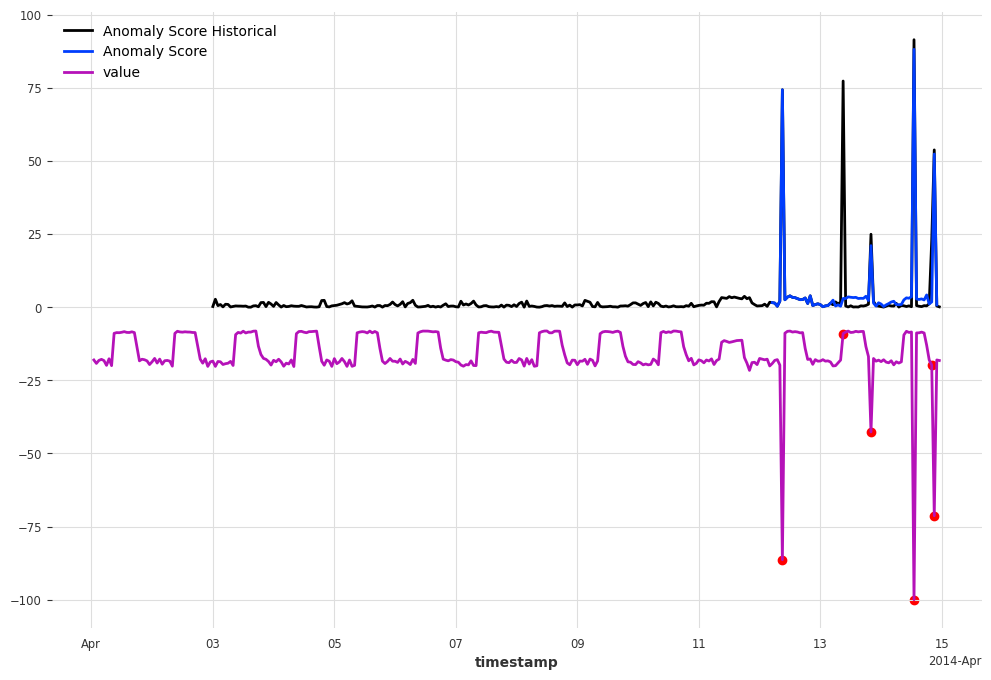

In [16]:
anom_scores_hfc_df = anomaly_scores_historical_fcast.to_dataframe().set_axis(['value'], axis=1)
threshold = 20
outliers_hfc = anom_scores_hfc_df[anom_scores_hfc_df['value'] > threshold]

anom_scores_df = anomaly_scores.to_dataframe().set_axis(['value'], axis=1)
outliers = anom_scores_df[anom_scores_df['value'] > threshold]

fig, axes = plt.subplots(1, 1, figsize=(12,8))

# plt.scatter(outliers_hfc.index, outliers_hfc['value'])
# plt.scatter(outliers.index, outliers['value'])
# fig.autofmt_xdate()

anomaly_scores_historical_fcast.plot(label='Anomaly Score Historical')
anomaly_scores.plot(label='Anomaly Score')

difference_hourly_df = difference_hourly.to_dataframe().set_axis(['value'], axis=1)
difference_hourly.drop_before(hfc_params['start']).plot()
plt.scatter(difference_hourly_df[difference_hourly_df.index.isin(outliers_hfc.index)].index,
            difference_hourly_df[difference_hourly_df.index.isin(outliers_hfc.index)]['value'],
            color='r'
    )


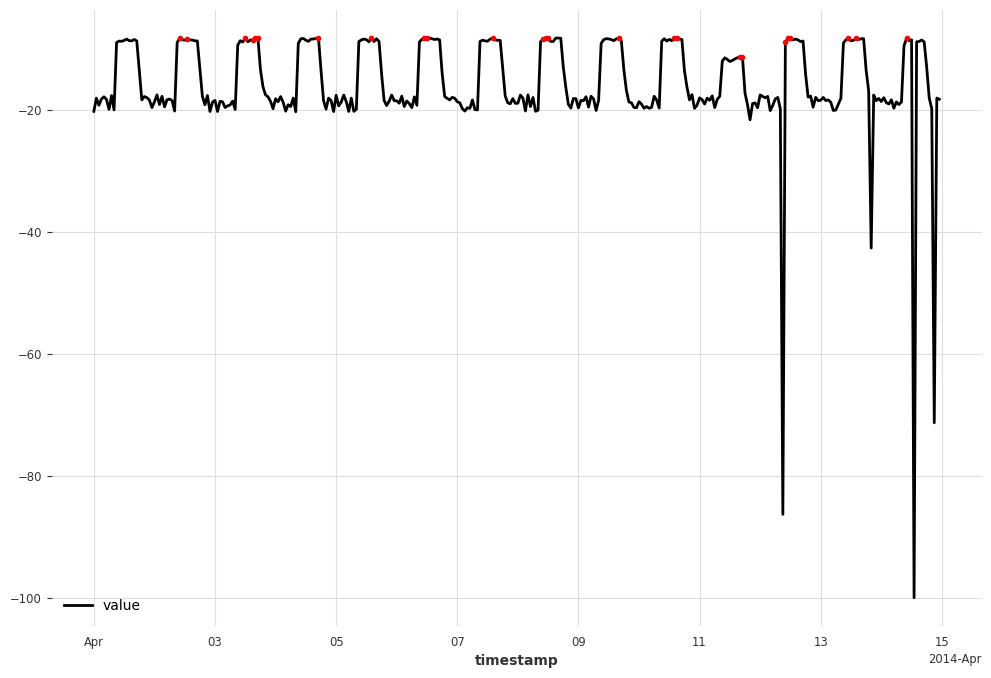

In [17]:
rolling_threshold = ThresholdConfig(difference_hourly_df)
rolling_threshold.rolling_window(window=24, threshold=0.95)

fig, axes = plt.subplots(1, 1, figsize=(12,8))
difference_hourly.plot(ax=axes)
rolling_outliers = rolling_threshold.plot()

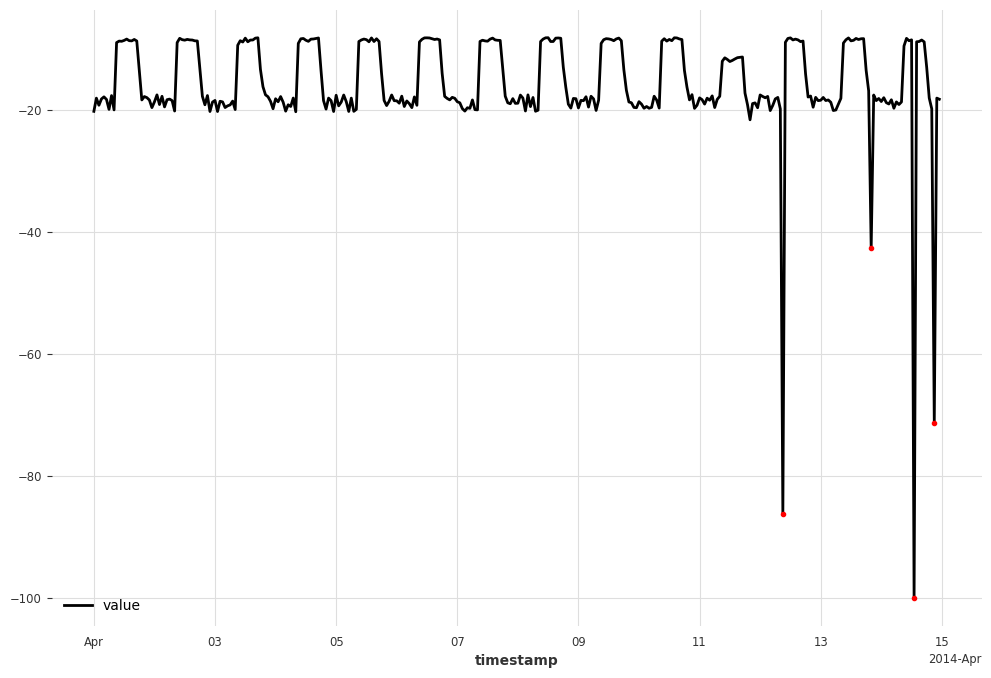

In [18]:
win = 24
# z_score = (difference_hourly_df.value - difference_hourly_df.rolling(24).mean())
# difference_hourly_df.value
z_score_test = ((difference_hourly_df - difference_hourly_df.rolling(win).mean().fillna(0)) / difference_hourly_df.rolling(24).std().fillna(1))[win:]
zscore_threshold = ThresholdConfig(difference_hourly_df)
zscore_threshold.z_score(win, 2)

fig, axes = plt.subplots(1, 1, figsize=(12,8))
difference_hourly.plot(ax=axes)
zscore_outliers = zscore_threshold.plot()



336


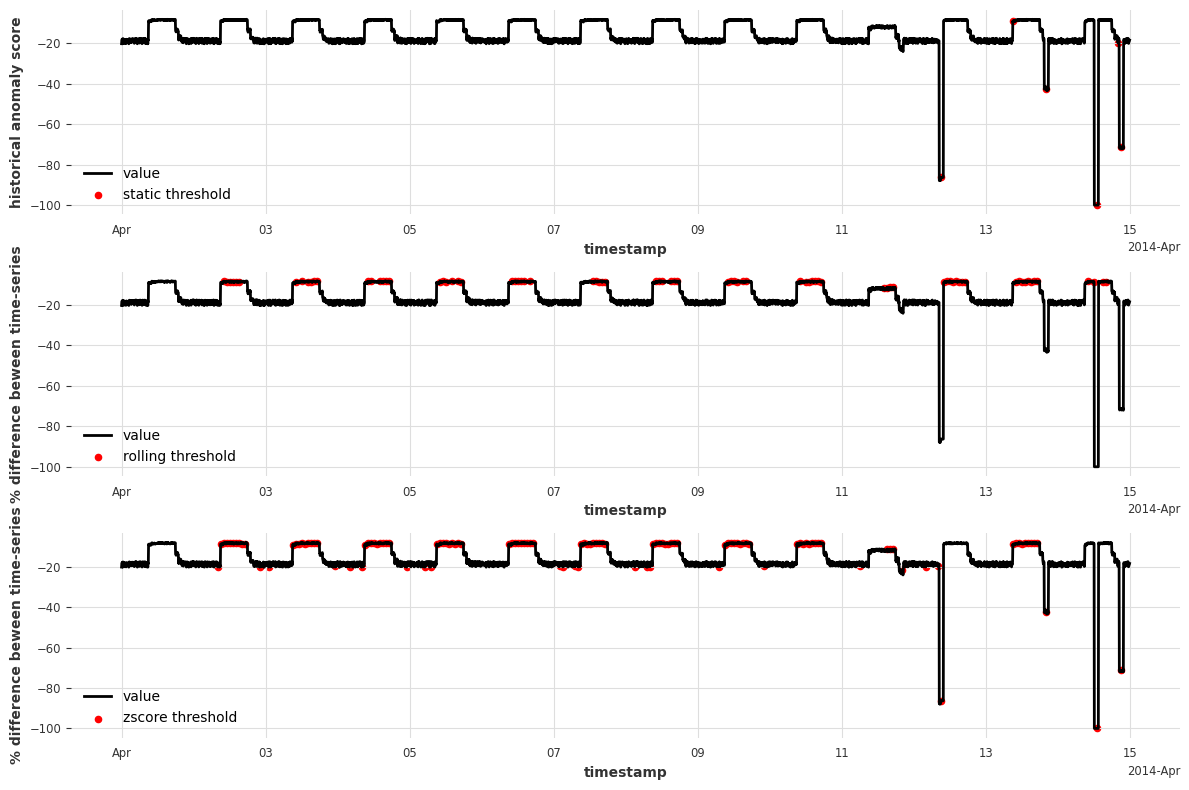

In [19]:
static_threshold = ThresholdConfig(difference_hourly_df)
print(difference_hourly_df.size)
static_outliers = static_threshold.static(20, anom_scores_hfc_df)

rolling_threshold = ThresholdConfig(difference_hourly_df)
rolling_outliers = rolling_threshold.rolling_window(24, 0.75)

zscore_threshold = ThresholdConfig(difference_hourly_df)
zscore_outliers = zscore_threshold.z_score(24, 1)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

for ax in axes:
    difference_ts.plot(x='timestamp', ax=ax)

# anom_scores_hfc_df.reset_index().plot(x='timestamp', ax=axes[0], label='hfc anomaly score')

static_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', ax=axes[0], label='static threshold')
rolling_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', ax=axes[1], label='rolling threshold')
zscore_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', ax=axes[2], label='zscore threshold')

axes[0].set_ylabel("historical anomaly score")
axes[1].set_ylabel("% difference beween time-series")
axes[2].set_ylabel("% difference beween time-series")
fig.tight_layout()
# static_outliers.plot

<Axes: xlabel='timestamp', ylabel='value'>

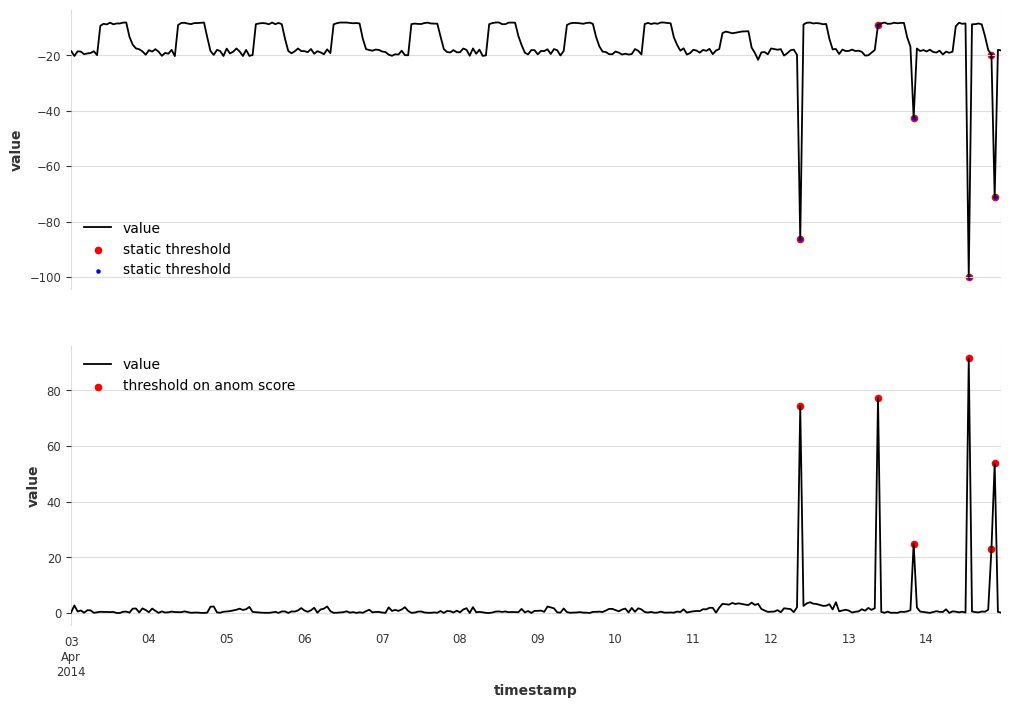

In [20]:
anom_score_threshold = ThresholdConfig.from_anomaly_score(anom_scores_hfc_df, difference_hourly_df)

anom_static_outliers = anom_score_threshold.static(20)


fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

difference_hourly_df.reset_index().plot(x='timestamp', ax=ax[0])
anom_static_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', label='static threshold', ax=ax[0])
static_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='b', s=5, label='static threshold', ax=ax[0])

anom_score_threshold.anomaly_score_df.plot(ax=ax[1])
anom_static_outliers_score = anom_score_threshold.static_on_score(20)
anom_static_outliers_score.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', label='threshold on anom score', ax=ax[1])

<Axes: xlabel='timestamp', ylabel='value'>

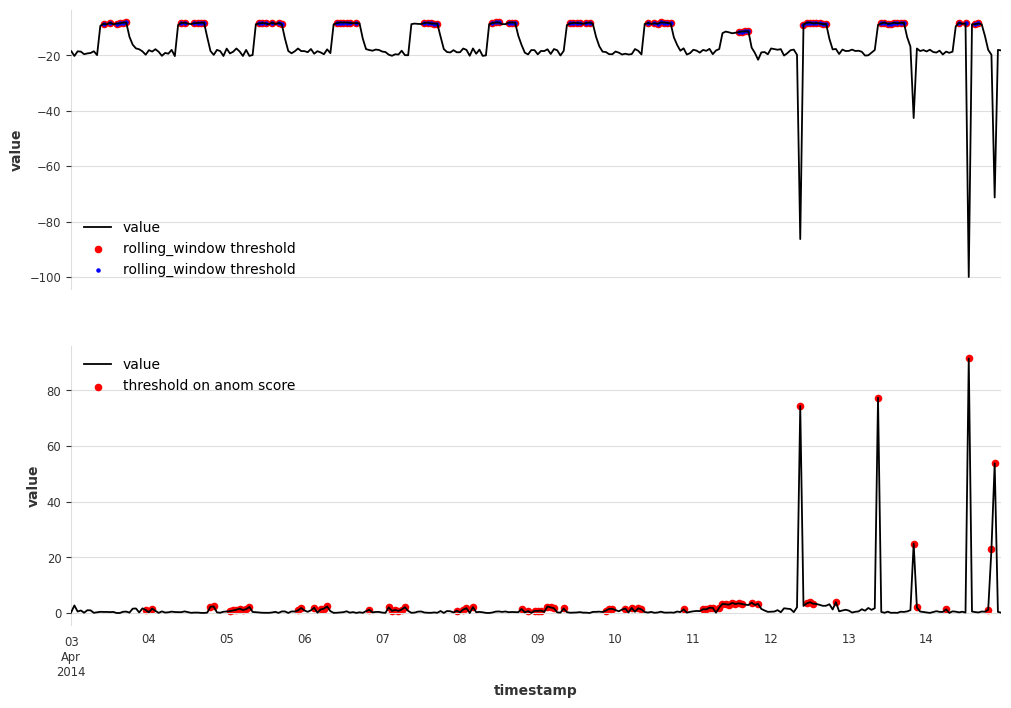

In [21]:
anom_score_threshold = ThresholdConfig.from_anomaly_score(anom_scores_hfc_df, difference_hourly_df)

anom_rolling_window_outliers = anom_score_threshold.rolling_window(24, 0.75)


fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

difference_hourly_df.reset_index().plot(x='timestamp', ax=ax[0])
anom_rolling_window_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', label='rolling_window threshold', ax=ax[0])
rolling_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='b', s=5, label='rolling_window threshold', ax=ax[0])

anom_score_threshold.anomaly_score_df.plot(ax=ax[1])
anom_rolling_window_outliers_score = anom_score_threshold.rolling_window_on_score(24, 0.75)
anom_rolling_window_outliers_score.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', label='threshold on anom score', ax=ax[1])

<Axes: xlabel='timestamp', ylabel='value'>

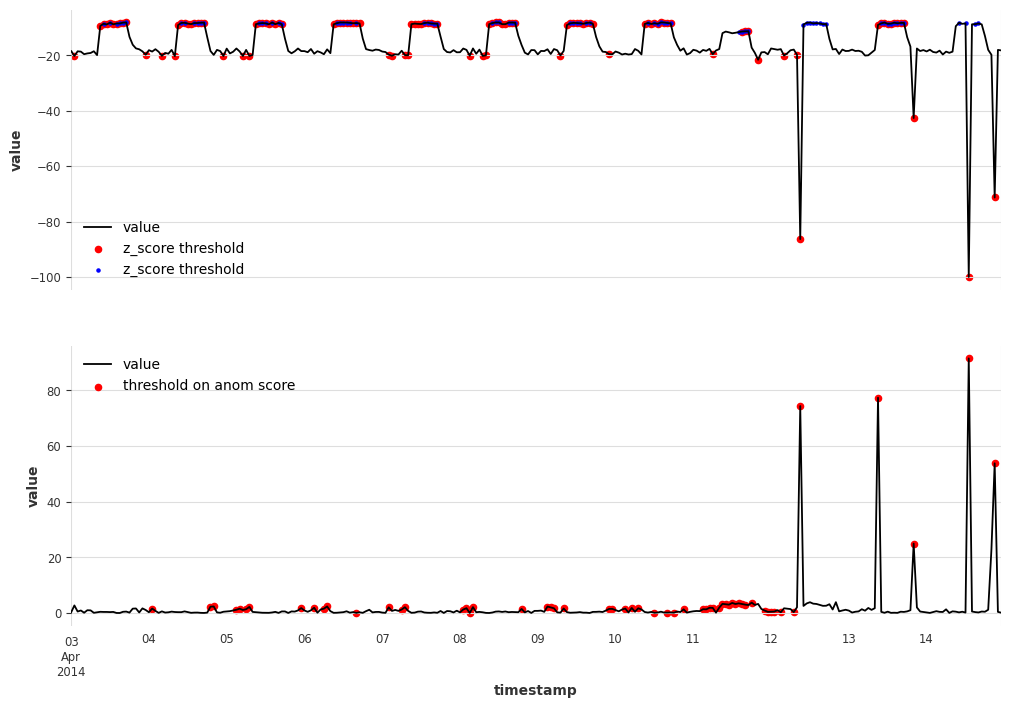

In [22]:
anom_score_threshold = ThresholdConfig.from_anomaly_score(anom_scores_hfc_df, difference_hourly_df)

anom_z_score_outliers = anom_score_threshold.z_score(24, 1)


fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

difference_hourly_df.reset_index().plot(x='timestamp', ax=ax[0])
anom_z_score_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', label='z_score threshold', ax=ax[0])
rolling_outliers.reset_index().plot(kind='scatter', x='timestamp', y='value', color='b', s=5, label='z_score threshold', ax=ax[0])

anom_score_threshold.anomaly_score_df.plot(ax=ax[1])
anom_z_score_outliers_score = anom_score_threshold.z_score_on_score(24, 1)
anom_z_score_outliers_score.reset_index().plot(kind='scatter', x='timestamp', y='value', color='r', label='threshold on anom score', ax=ax[1])